In [2]:
import os
ruta=os.path.join(os.getcwd(),'Files')

In [3]:
import importlib
import drive_utils.upload

importlib.reload(drive_utils.upload)

from drive_utils.upload import subir_o_actualizar_archivo


In [11]:
from drive_utils.auth import autenticar_drive
from drive_utils.upload import subir_o_actualizar_archivo

service = autenticar_drive()
subir_o_actualizar_archivo(service,os.path.join(ruta,"VBI_L1_20240703T192557_EZHXQL_metadata.asdf"))
subir_o_actualizar_archivo(service, os.path.join(ruta,"VBI_2024_07_03T19_25_57_740_00668400_I_EZHXQL_L1.fits"))
subir_o_actualizar_archivo(service, os.path.join(ruta,"VBI_2024_07_03T19_26_11_366_00668400_I_EZHXQL_L1.fits"))
subir_o_actualizar_archivo(service, os.path.join(ruta,"hmi.ic_45s.20240703_192615_TAI.2.continuum.fits"))

🔄 Archivo actualizado en Drive: VBI_L1_20240703T192557_EZHXQL_metadata.asdf
🔄 Archivo actualizado en Drive: VBI_2024_07_03T19_25_57_740_00668400_I_EZHXQL_L1.fits
🔄 Archivo actualizado en Drive: VBI_2024_07_03T19_26_11_366_00668400_I_EZHXQL_L1.fits
🔄 Archivo actualizado en Drive: hmi.ic_45s.20240703_192615_TAI.2.continuum.fits


## Loading dataset from an asdf file

In [4]:
from dkist import Dataset
asdf_file=os.path.join(ruta,'VBI_L1_20240703T192557_EZHXQL_metadata.asdf') #Carga el archivo asdf (advance scinetific document format
ds = Dataset.from_asdf(asdf_file) #Del asdf carga el dataset correspondiente, este archivo es de metadatos 
print(ds)

        Use load_dataset instead. [_py_warnings]


This VBI Dataset consists of 650 frames.
Files are stored in /home/daniel/Documentos/Maestría/Proyecto_Tesis/Files

This calibration has Dataset ID EZHXQL.
The unique identifier for the input observe frames (Product ID) is L1-UOQKY.

This Dataset has 3 pixel and 3 world dimensions.

The data are represented by a <class 'dask.array.core.Array'> object:
dask.array<reshape, shape=(650, 4096, 4096), dtype=float32, chunksize=(1, 4096, 4096), chunktype=numpy.ndarray>

Array Dim  Axis Name                  Data size  Bounds
        0  time                             650  None
        1  helioprojective latitude        4096  None
        2  helioprojective longitude       4096  None

World Dim  Axis Name                  Physical Type                   Units
        2  time                       time                            s
        1  helioprojective latitude   custom:pos.helioprojective.lat  arcsec
        0  helioprojective longitude  custom:pos.helioprojective.lon  arcsec

Correlation

## Observation time 

In [5]:
#Consultar los tiempos de observación 
from astropy.io import fits

file0=os.path.join(ruta,ds.files.filenames[0])
file2=os.path.join(ruta, ds.files.filenames[2])

with fits.open(file0) as hdul:
    hdr = hdul[1].header  #Header del "tiempo 0"
    time0 = hdr['DATE-BEG'] 
    print(time0)
with fits.open(file2) as HDUL:
    HDR = HDUL[1].header   #Header del "tiempo 2"
    time2=HDR['DATE-BEG']
print(time2)

2024-07-03T19:25:57.740
2024-07-03T19:26:11.366


## Plotting the DKIST files

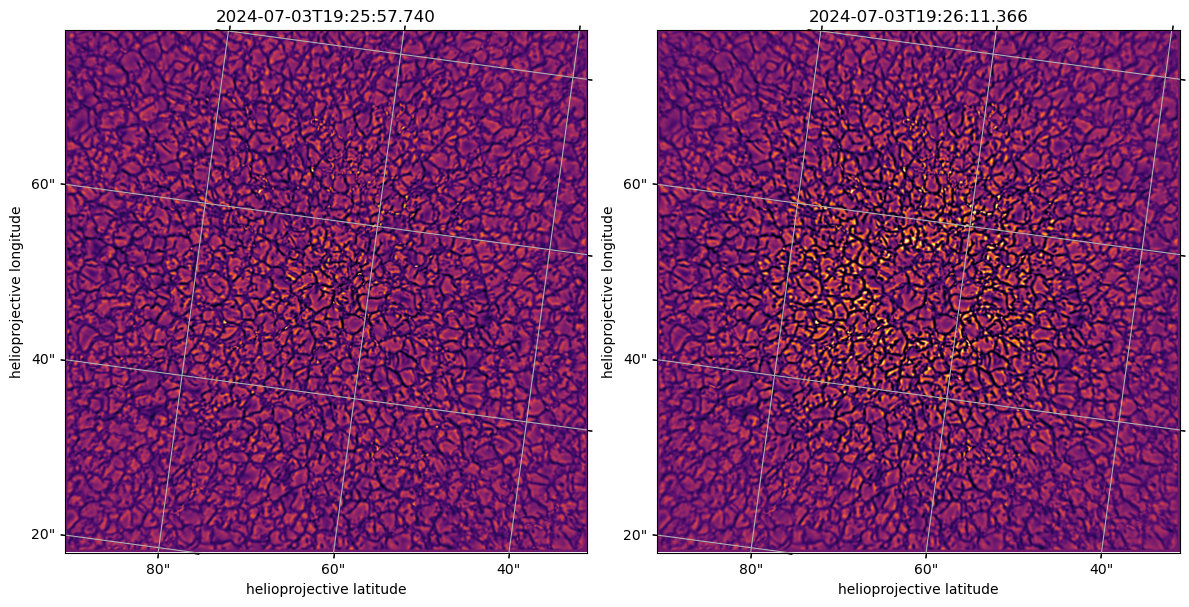

In [6]:
import matplotlib.pyplot as plt

im0 = ds[0].data.compute() #Lee con mayor detalle el archivo del dataset así como el fits 
im2 = ds[2].data.compute()

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(1, 2, 1, projection=ds[0].wcs) # 1 fila, 2 columnas y esta se encuentra en la 1era columna// wcs: World Coordinate System del fits
ax2 = fig.add_subplot(1, 2, 2, projection=ds[2].wcs)

ax1.imshow(im0, origin='lower', vmin=20000, vmax=80000, cmap='inferno') #Configuración de la visualización de la figura respectiva
ax1.set_title(f"{time0}")
ax1.grid(True)

ax2.imshow(im2, origin='lower', vmin=20000, vmax=80000, cmap='inferno')
ax2.set_title(f"{time2}")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [7]:
from sunpy.map import Map

# Abrir como SunPy Map desde el archivo FITS
smap0 = Map(file0)
smap2 = Map(file2)

# Ahora smap0.wcs es un WCS manipulable tradicional

In [8]:
from astropy.wcs import WCS

orig_wcs = smap0.wcs.low_level_wcs
hdr = orig_wcs.to_header()  # usar header original
wcs_rot = WCS(hdr)

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,crln_obs,dsun_obs
 [sunpy.map.mapbase]


## Rotation of the pixel to make their axis parallel with the axis of the World (Helioprojectives Coordinates)

In [9]:
import numpy as np

#Rotation Matrix: 
pc = np.array([
    [hdr['PC1_1'], hdr['PC1_2']],
    [hdr['PC2_1'], hdr['PC2_2']]
]) #Also it is given by: smap0.wcs.pc

cdelt = np.array([hdr['CDELT1'], hdr['CDELT2']])

cd = pc * cdelt

print("CD matrix [arcsec/pix]:")
print(cd)

theta = np.degrees(np.arctan2(pc[1,0], pc[1,1])) # sen x / cos x = tan x 
print(f"Rotación ≈ {theta:.2f} grados")

print('PC: ',pc)
print('PC via header: ', wcs_rot.wcs.pc)

CD matrix [arcsec/pix]:
[[ 5.44432903e-07  4.04214749e-06]
 [-4.04149733e-06  5.44515423e-07]]
Rotación ≈ -82.33 grados
PC:  [[ 0.12634446  0.9380457 ]
 [-0.93789482  0.12636361]]
PC via header:  [[ 0.12634446  0.9380457 ]
 [-0.93789482  0.12636361]]


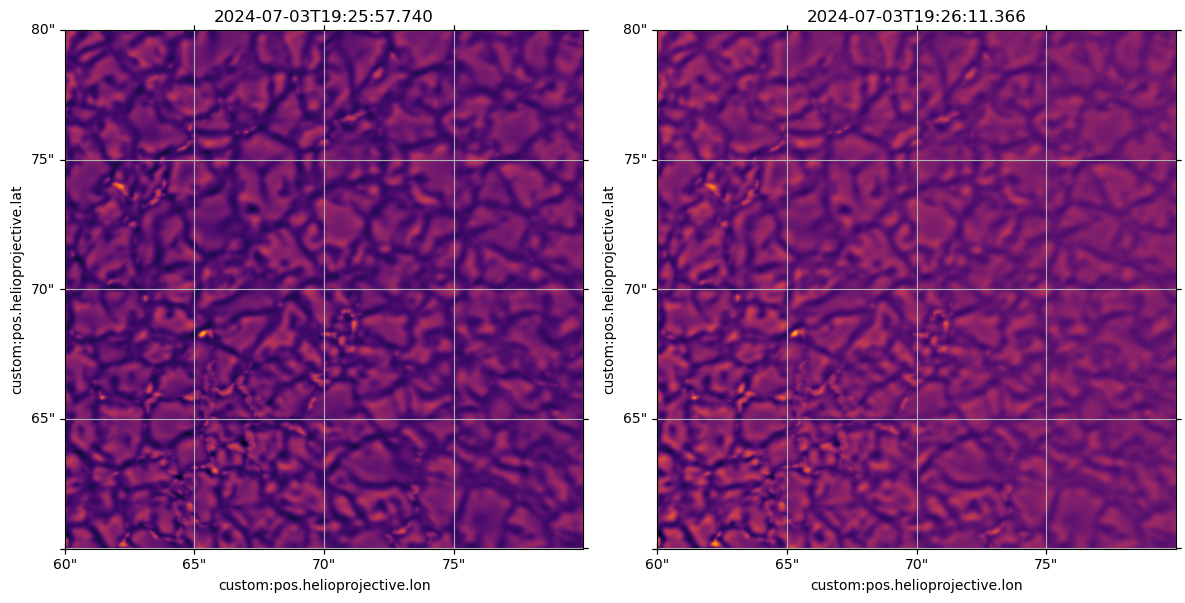

In [11]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from reproject import reproject_interp

# =====================================================
# 1. Parámetros
# =====================================================
theta=-theta
roi_bl = SkyCoord(60*u.arcsec, 60*u.arcsec, frame=smap0.coordinate_frame) #bottom left
roi_tr = SkyCoord(80*u.arcsec, 80*u.arcsec, frame=smap0.coordinate_frame) #righ top

# =====================================================
# 2. WCS original
# =====================================================
orig_wcs = smap0.wcs.low_level_wcs
wcs_rot = WCS(orig_wcs.to_header())

# =====================================================
# 3. Centro del mapa (pivote de rotación)
# =====================================================
ny, nx = smap0.data.shape
cx = (nx - 1) / 2
cy = (ny - 1) / 2

# =====================================================
# 4. Matriz de rotación
# =====================================================
theta_rad = np.deg2rad(theta)

R = np.array([
    [np.cos(theta_rad), -np.sin(theta_rad)],
    [np.sin(theta_rad),  np.cos(theta_rad)]
])

# =====================================================
# 5. Rotar alrededor del centro
# =====================================================
# mover centro al origen
wcs_rot.wcs.crpix -= np.array([cx, cy])

# rotar ejes
wcs_rot.wcs.pc = R @ wcs_rot.wcs.pc

# devolver centro
wcs_rot.wcs.crpix += np.array([cx, cy])

# =====================================================
# 6. Aumentar tamaño para evitar cortes
# =====================================================
scale = np.sqrt(2)
ny_out = int(np.ceil(scale * ny))
nx_out = int(np.ceil(scale * nx))

# ajustar CRPIX al nuevo tamaño
wcs_rot.wcs.crpix += np.array([
    (nx_out - nx) / 2,
    (ny_out - ny) / 2
])

# =====================================================
# 7. Reproyección (NO modifica archivos originales)
# =====================================================
data0_rot, _ = reproject_interp(
    (smap0.data, smap0.wcs),
    wcs_rot,
    shape_out=(ny_out, nx_out)
)

data2_rot, _ = reproject_interp(
    (smap2.data, smap2.wcs),
    wcs_rot,
    shape_out=(ny_out, nx_out)
)

# =====================================================
# 8. Gráfica con ROI en coordenadas helioproyectivas
# =====================================================
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=wcs_rot)
ax0.imshow(data0_rot, origin='lower', cmap='inferno')
ax0.grid(True)
ax0.set_title(f"{time0}")

# ROI → píxeles
x0, y0 = wcs_rot.world_to_pixel(roi_bl)
x1, y1 = wcs_rot.world_to_pixel(roi_tr)

ax0.set_xlim(x0, x1)
ax0.set_ylim(y0, y1)

# -----------------------------------------------------

ax2 = fig.add_subplot(1, 2, 2, projection=wcs_rot)
ax2.imshow(data2_rot, origin='lower', cmap='inferno')
ax2.grid(True)
ax2.set_title(f"{time2}")

ax2.set_xlim(x0, x1)
ax2.set_ylim(y0, y1)

plt.tight_layout()
plt.show()